# KNN Motivation

- Lazy motivation
    - Any approaches does not make any assumption on underlying data
    - Just store dataset without learning from it
    - Start classifying data when it receive Test data
    - It take less time learning    

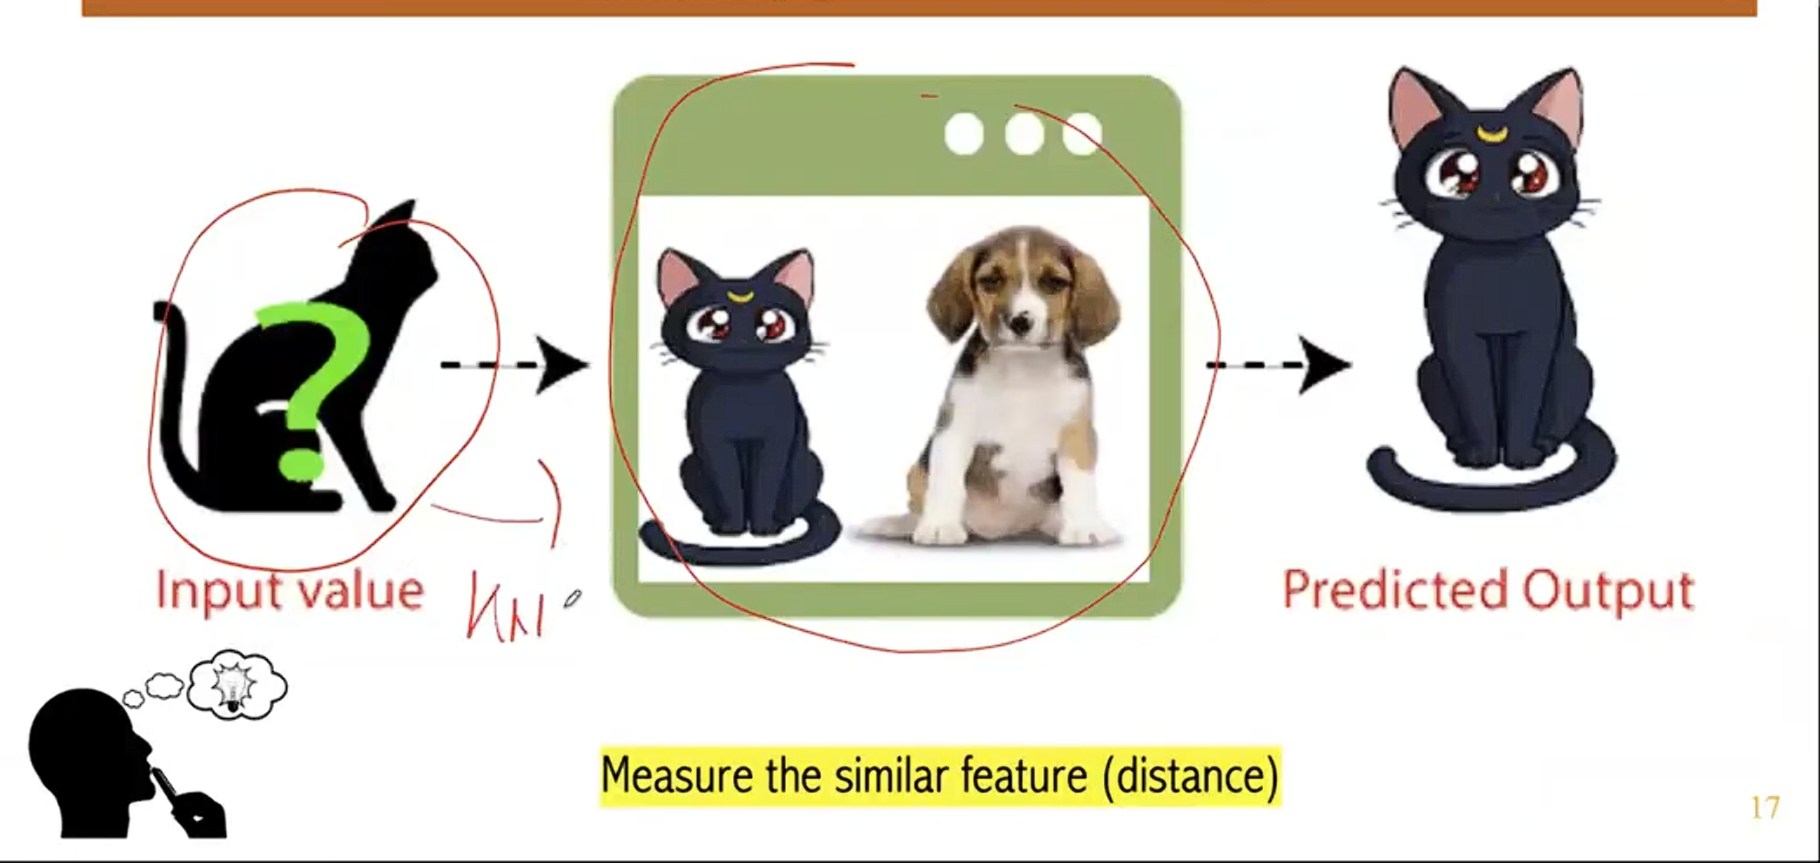



# KNN for classification

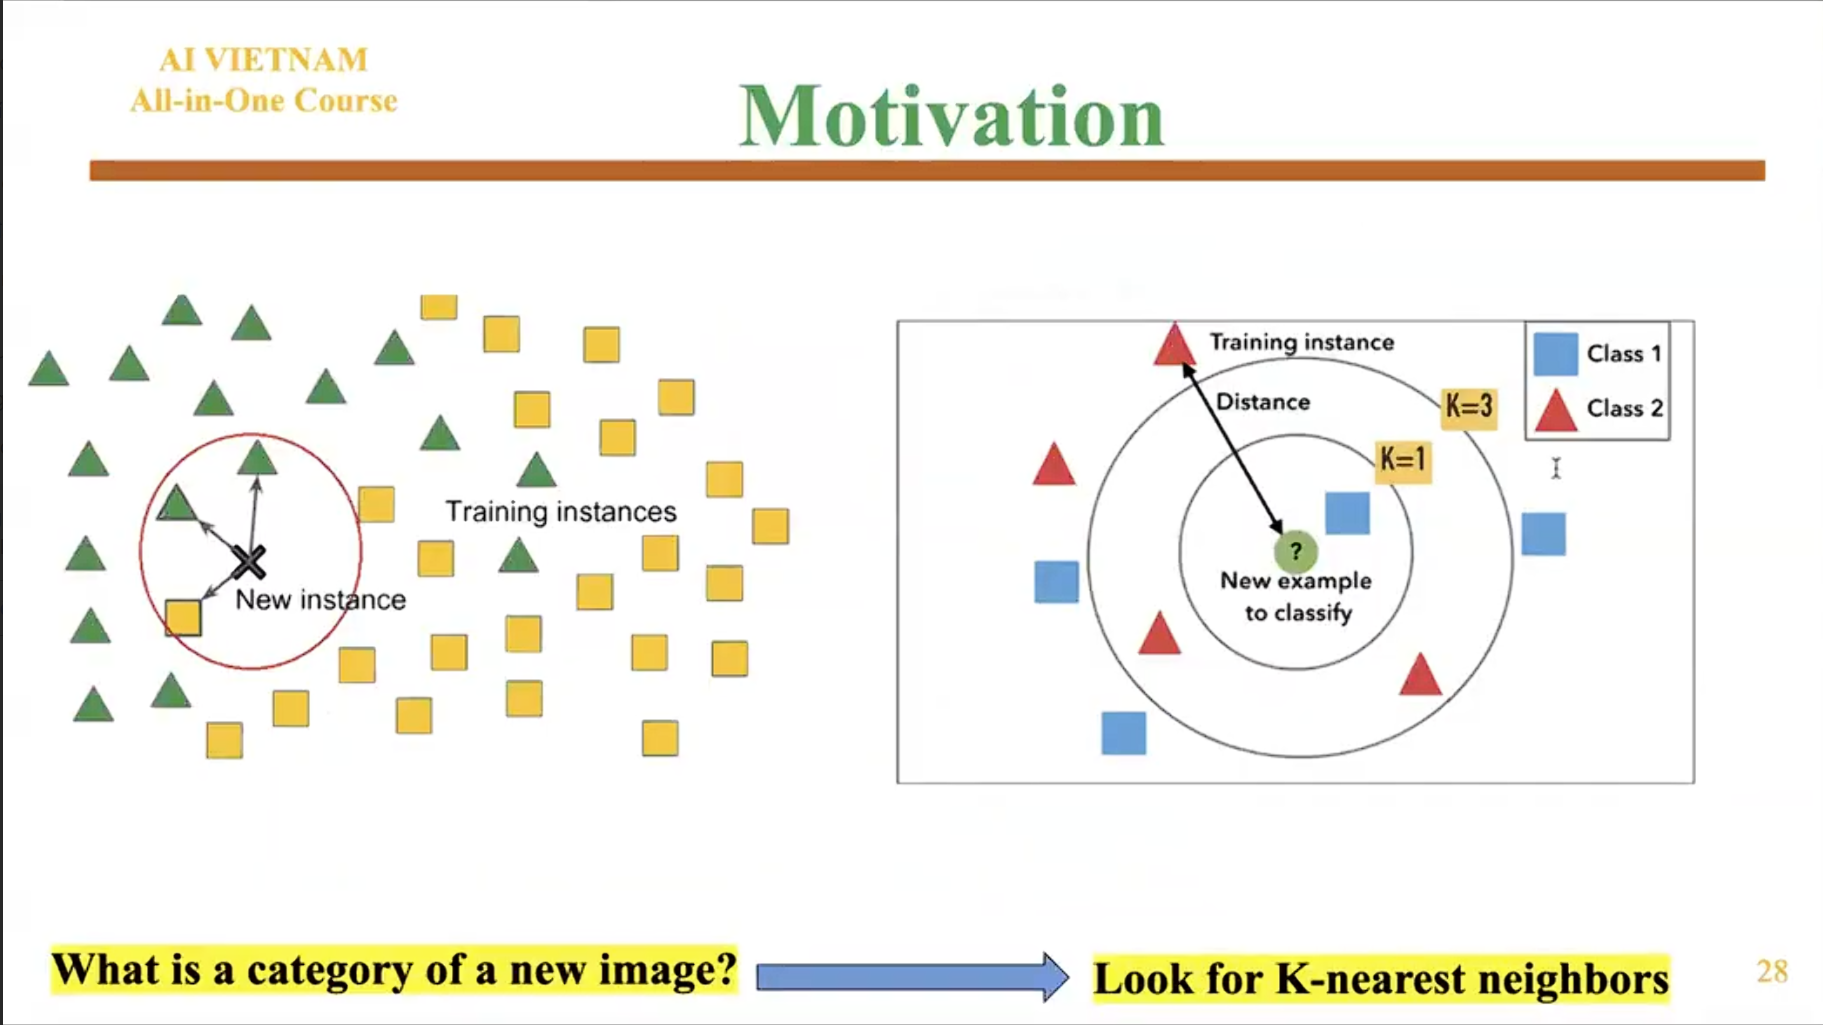
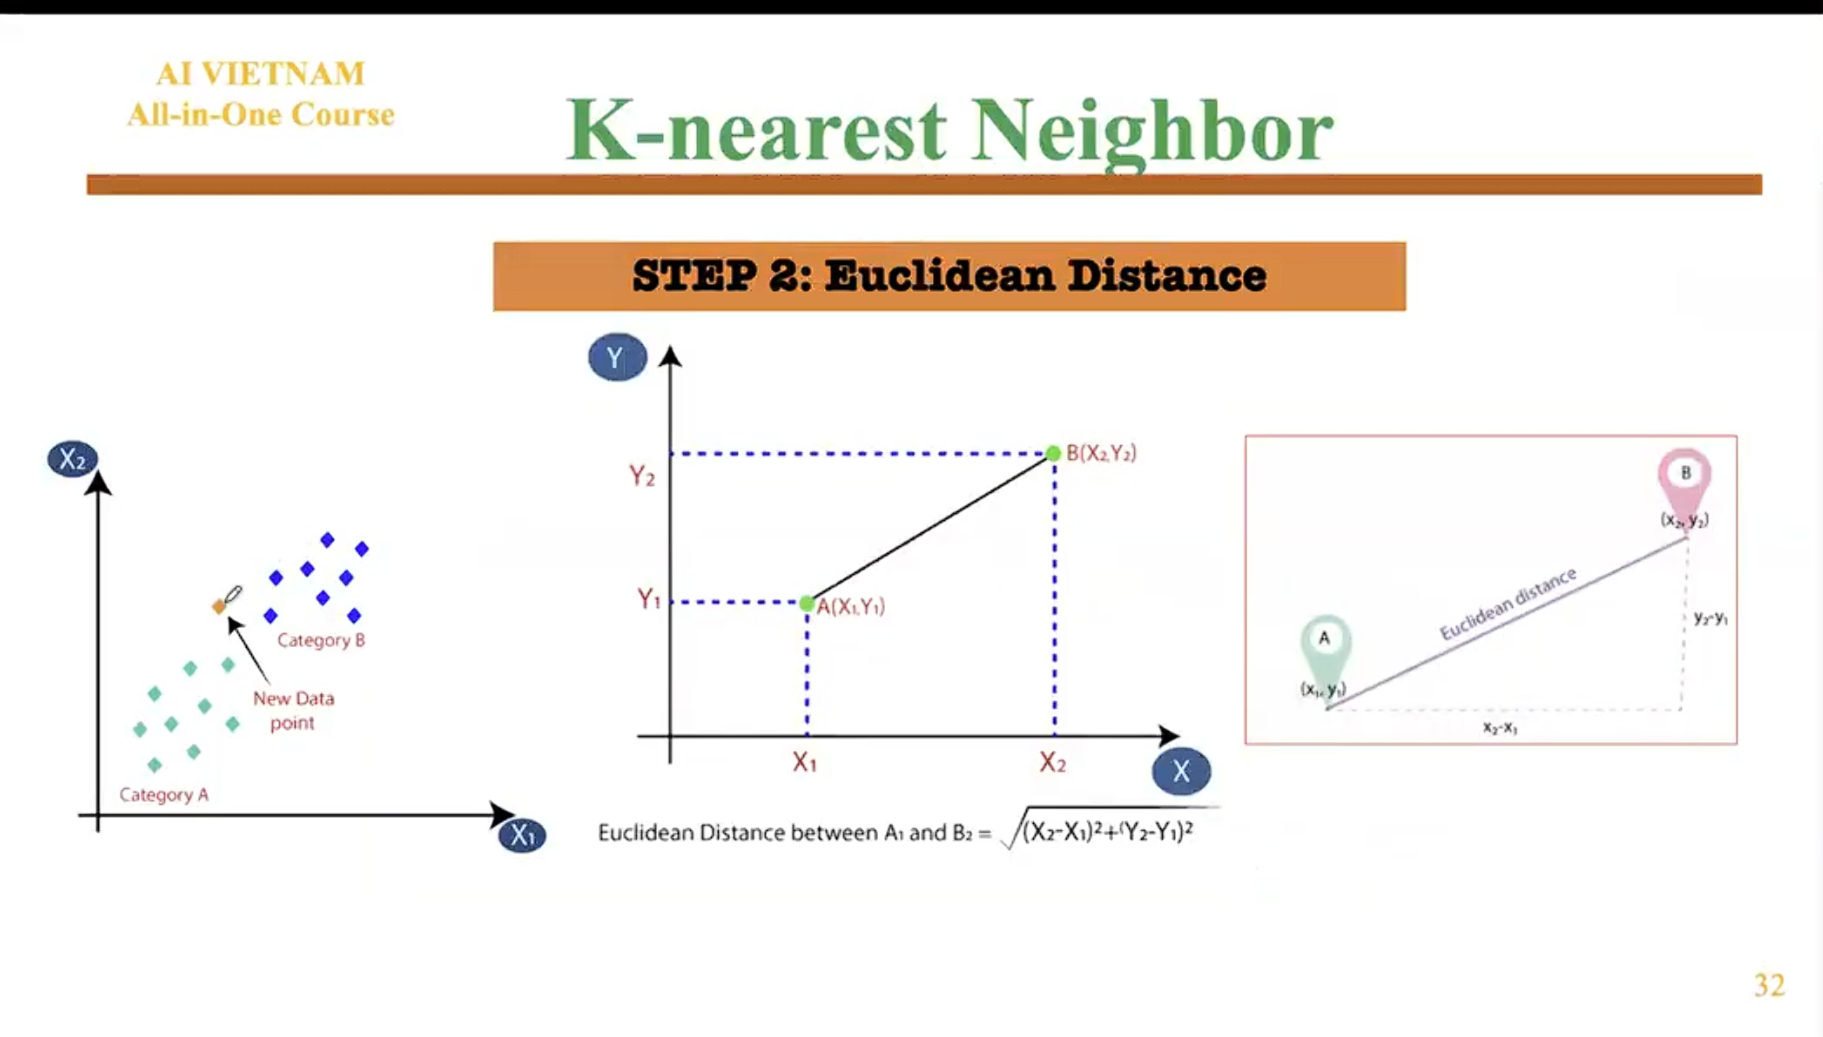
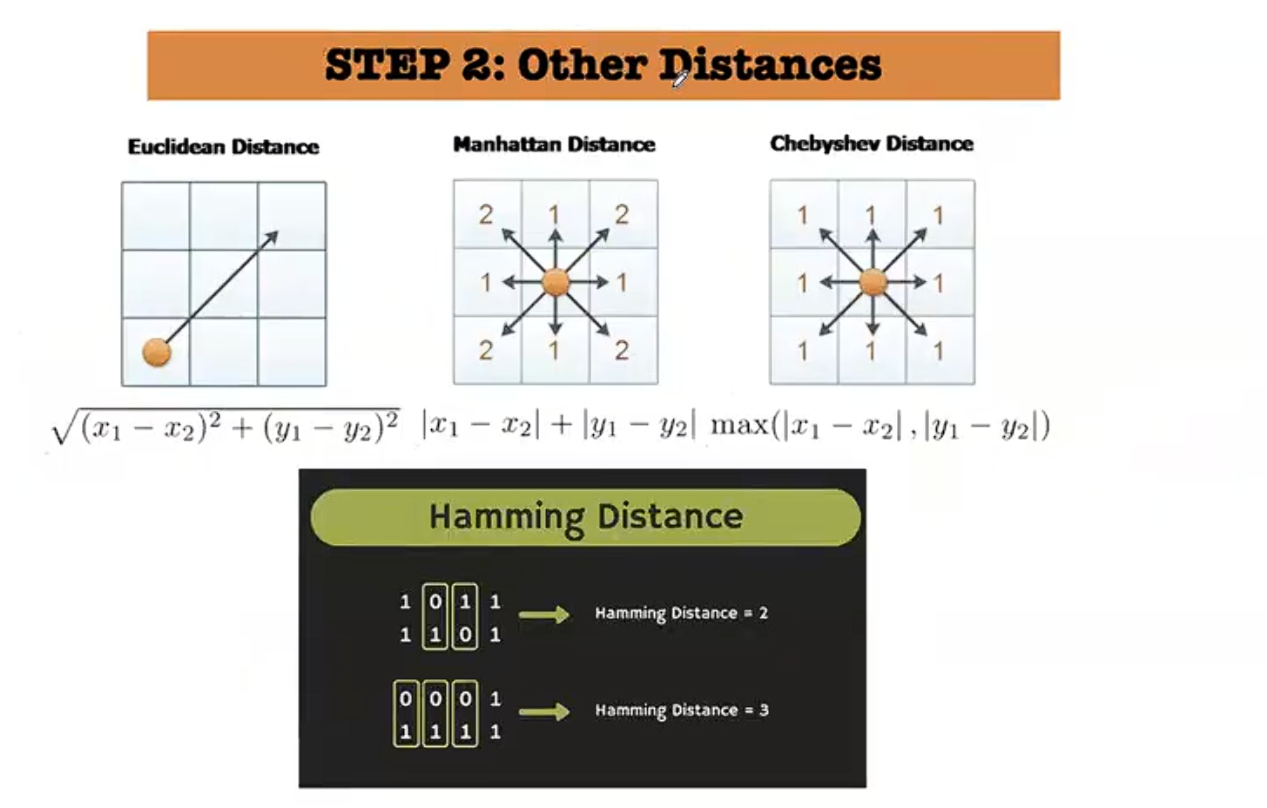
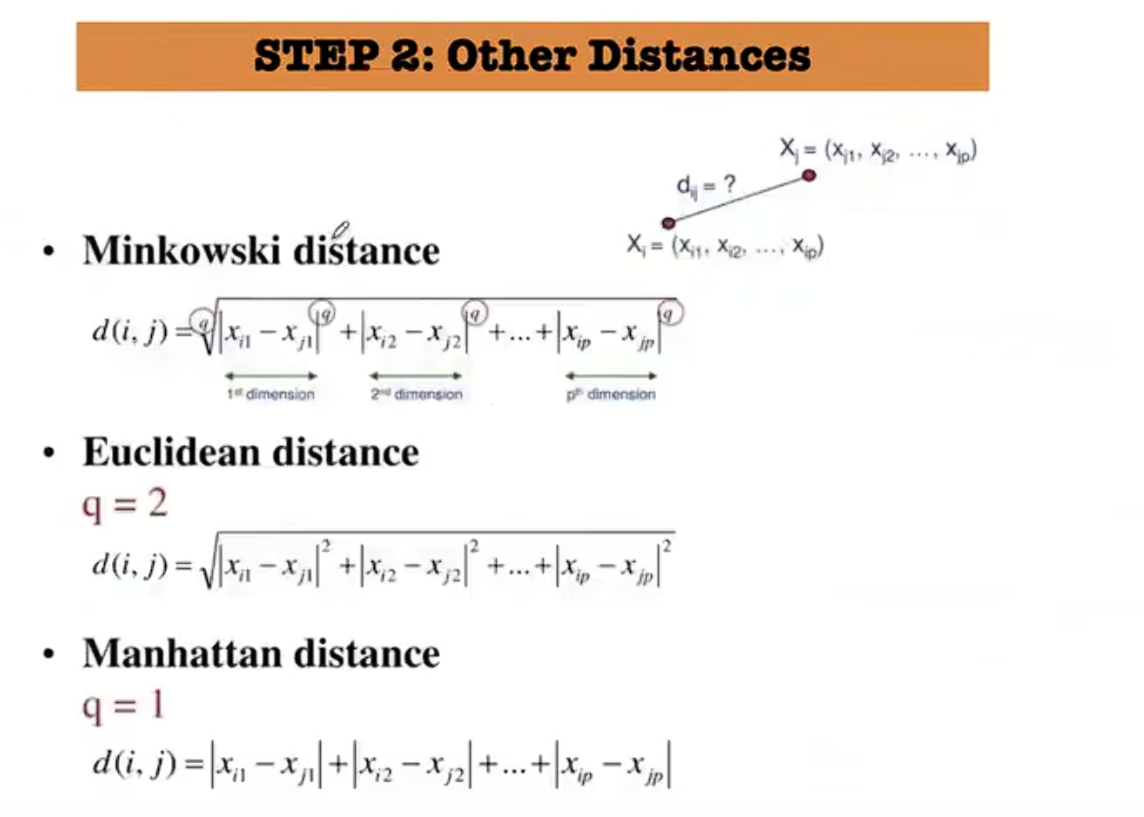
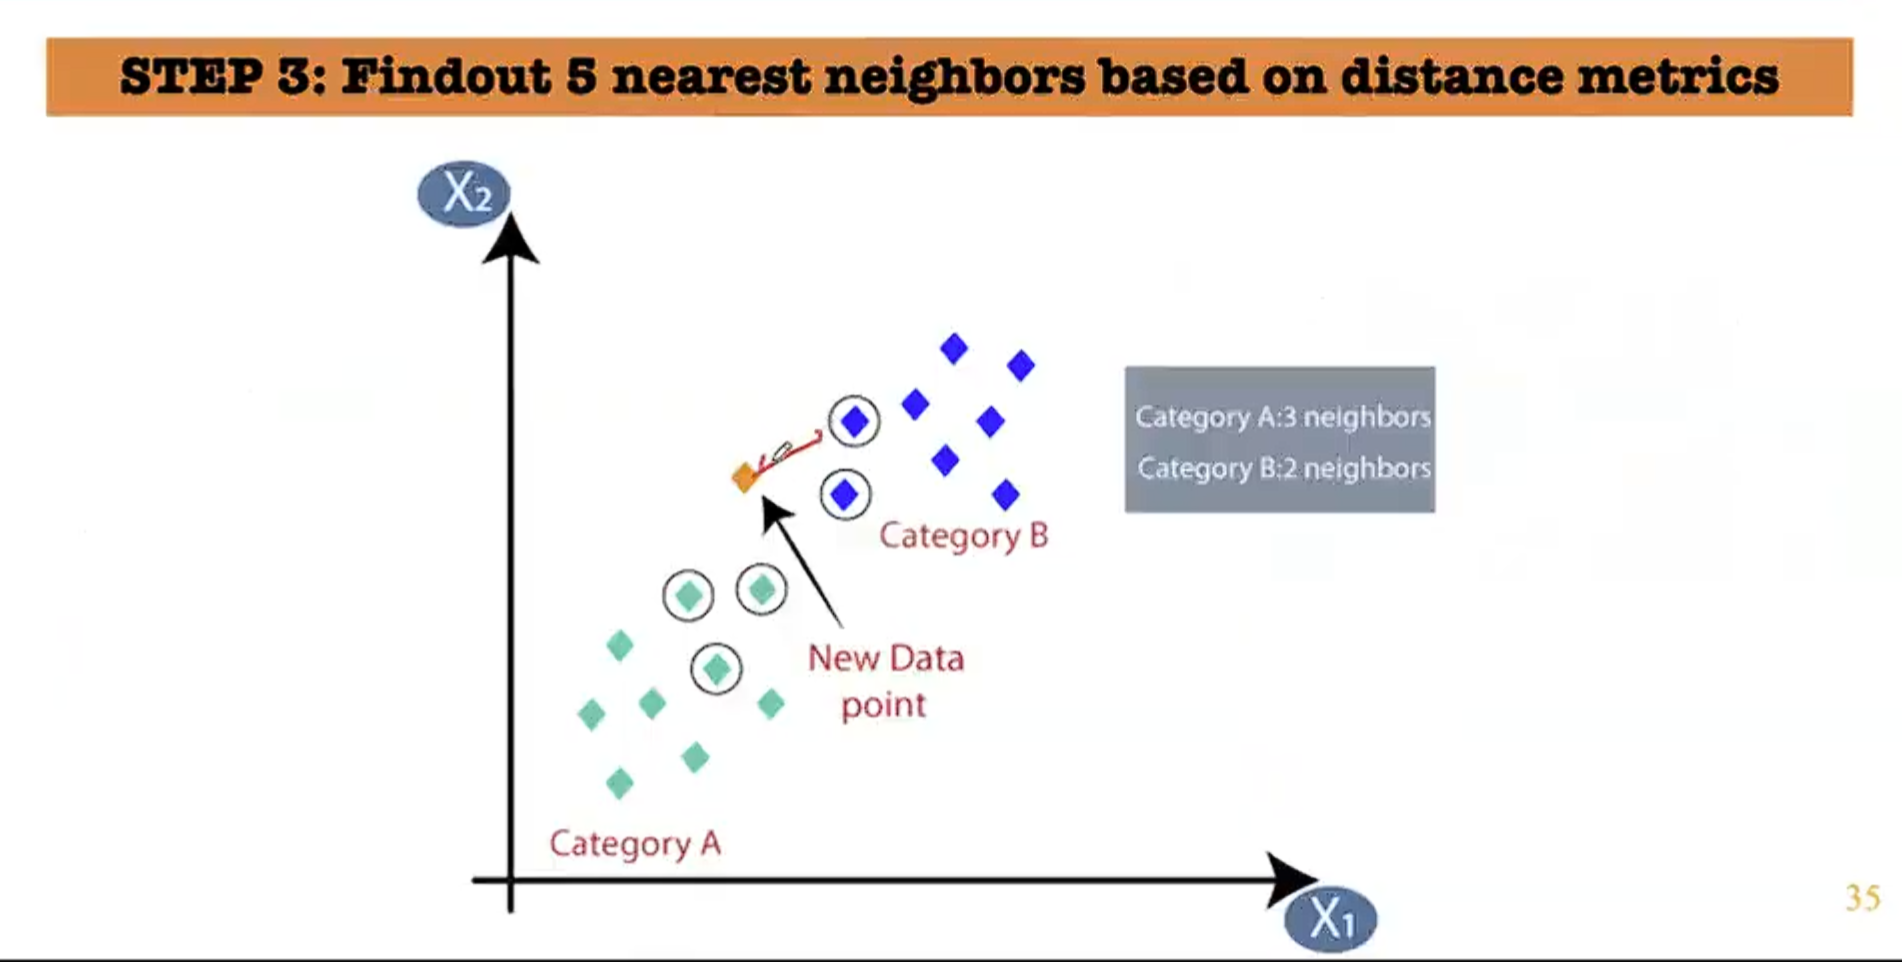


# How to select k in KNN

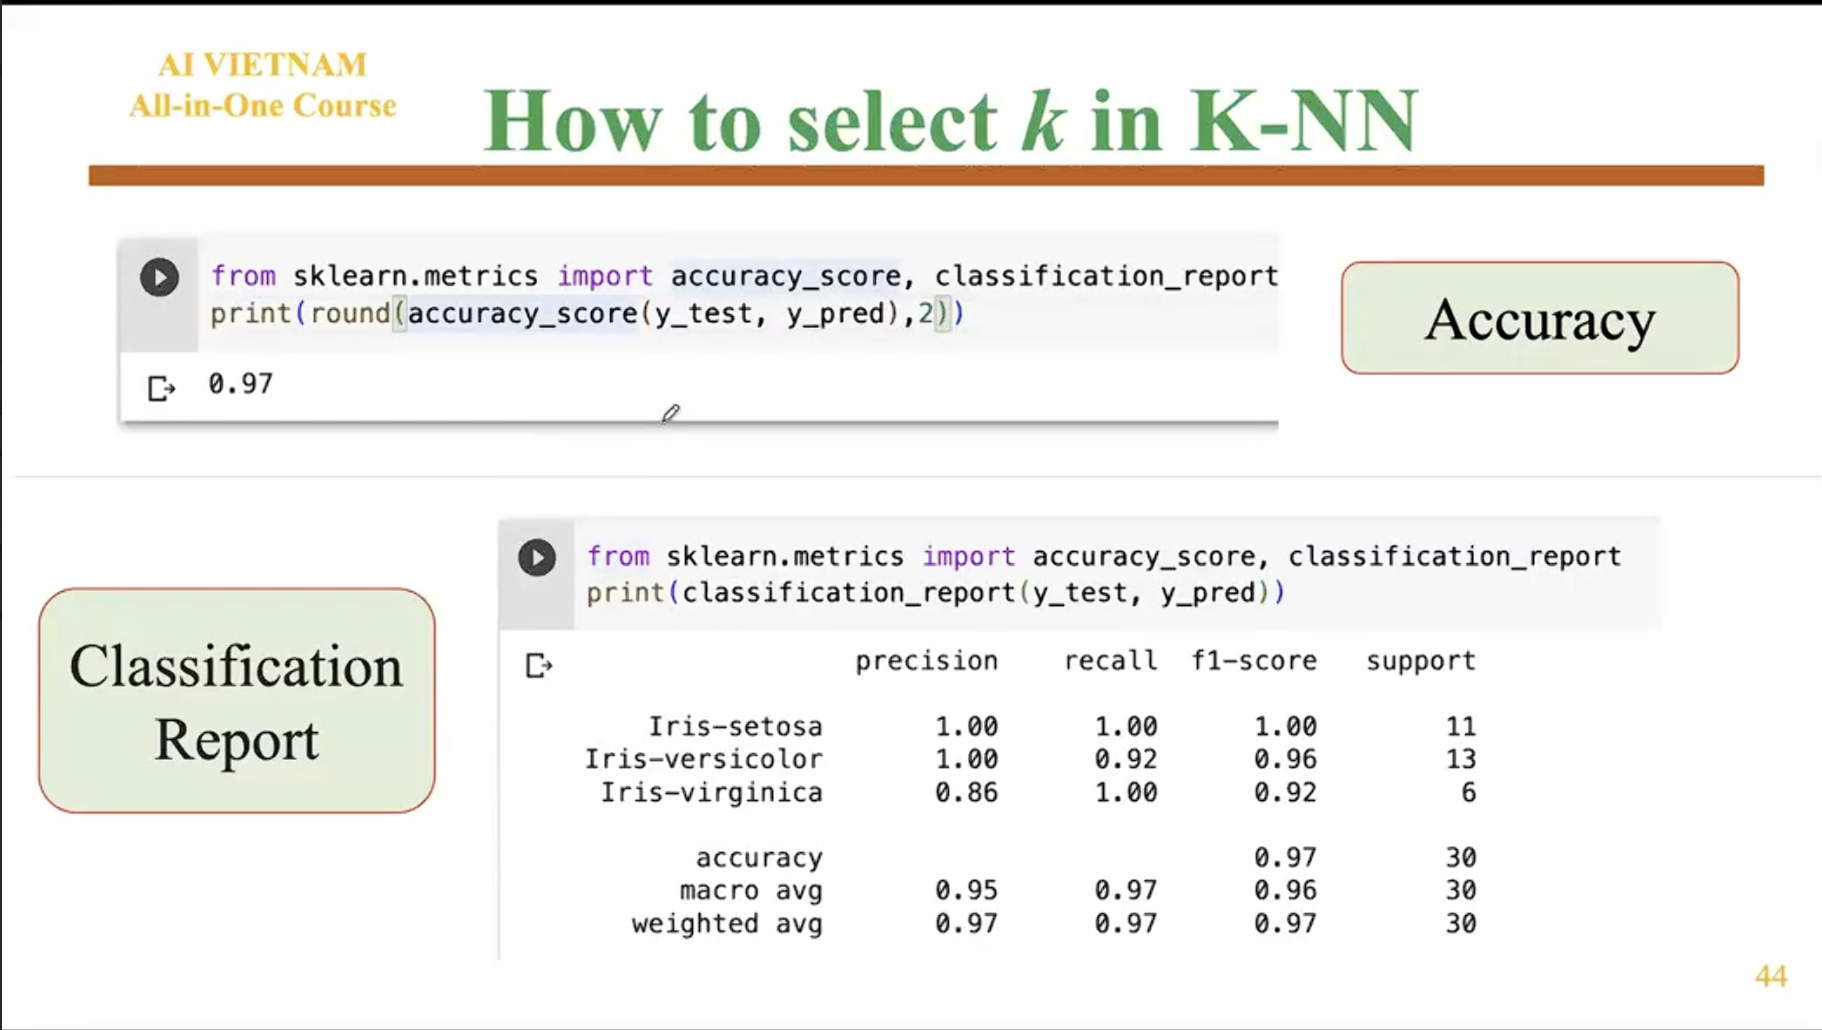
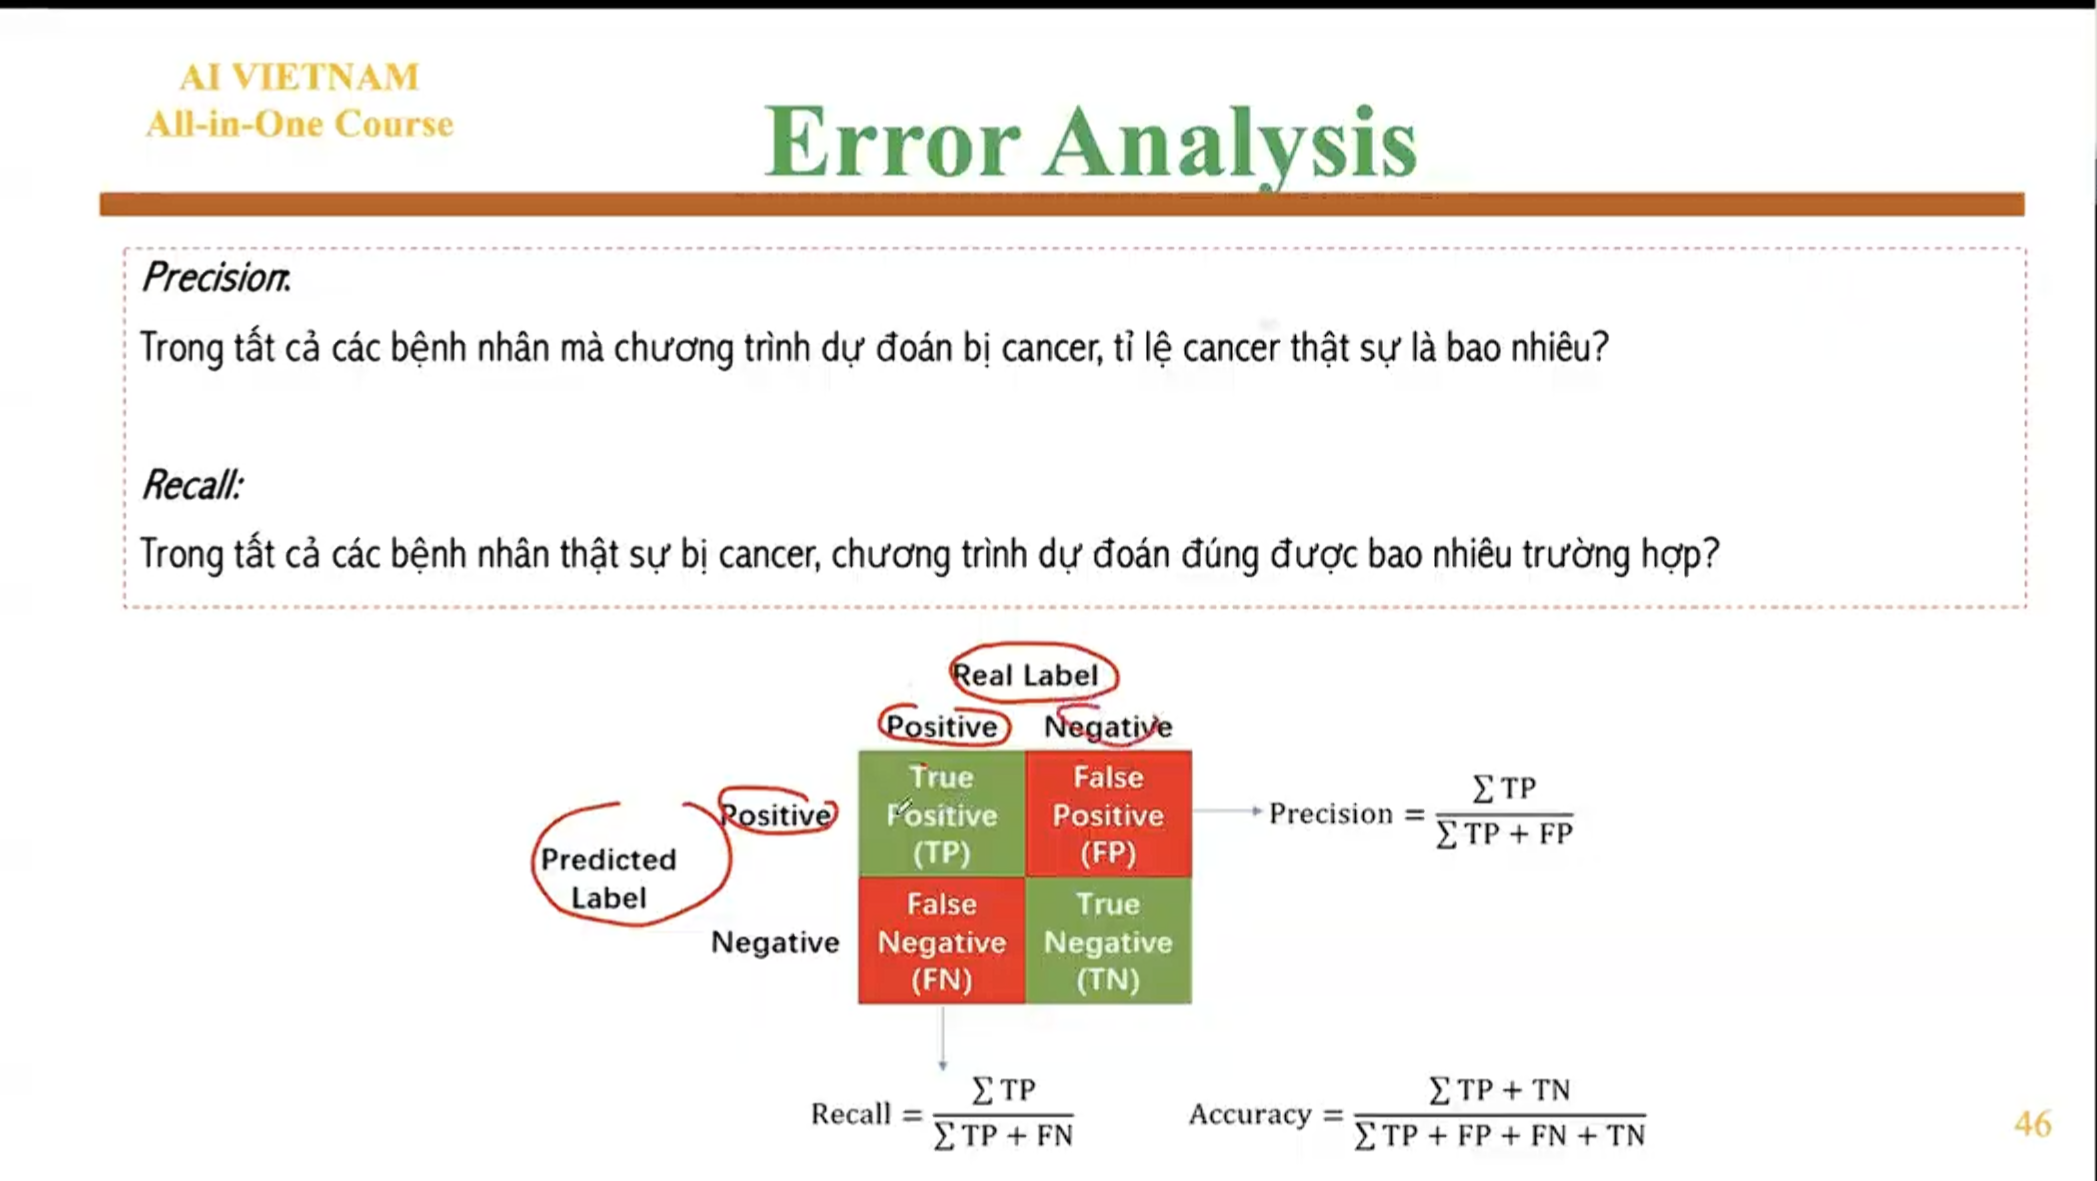
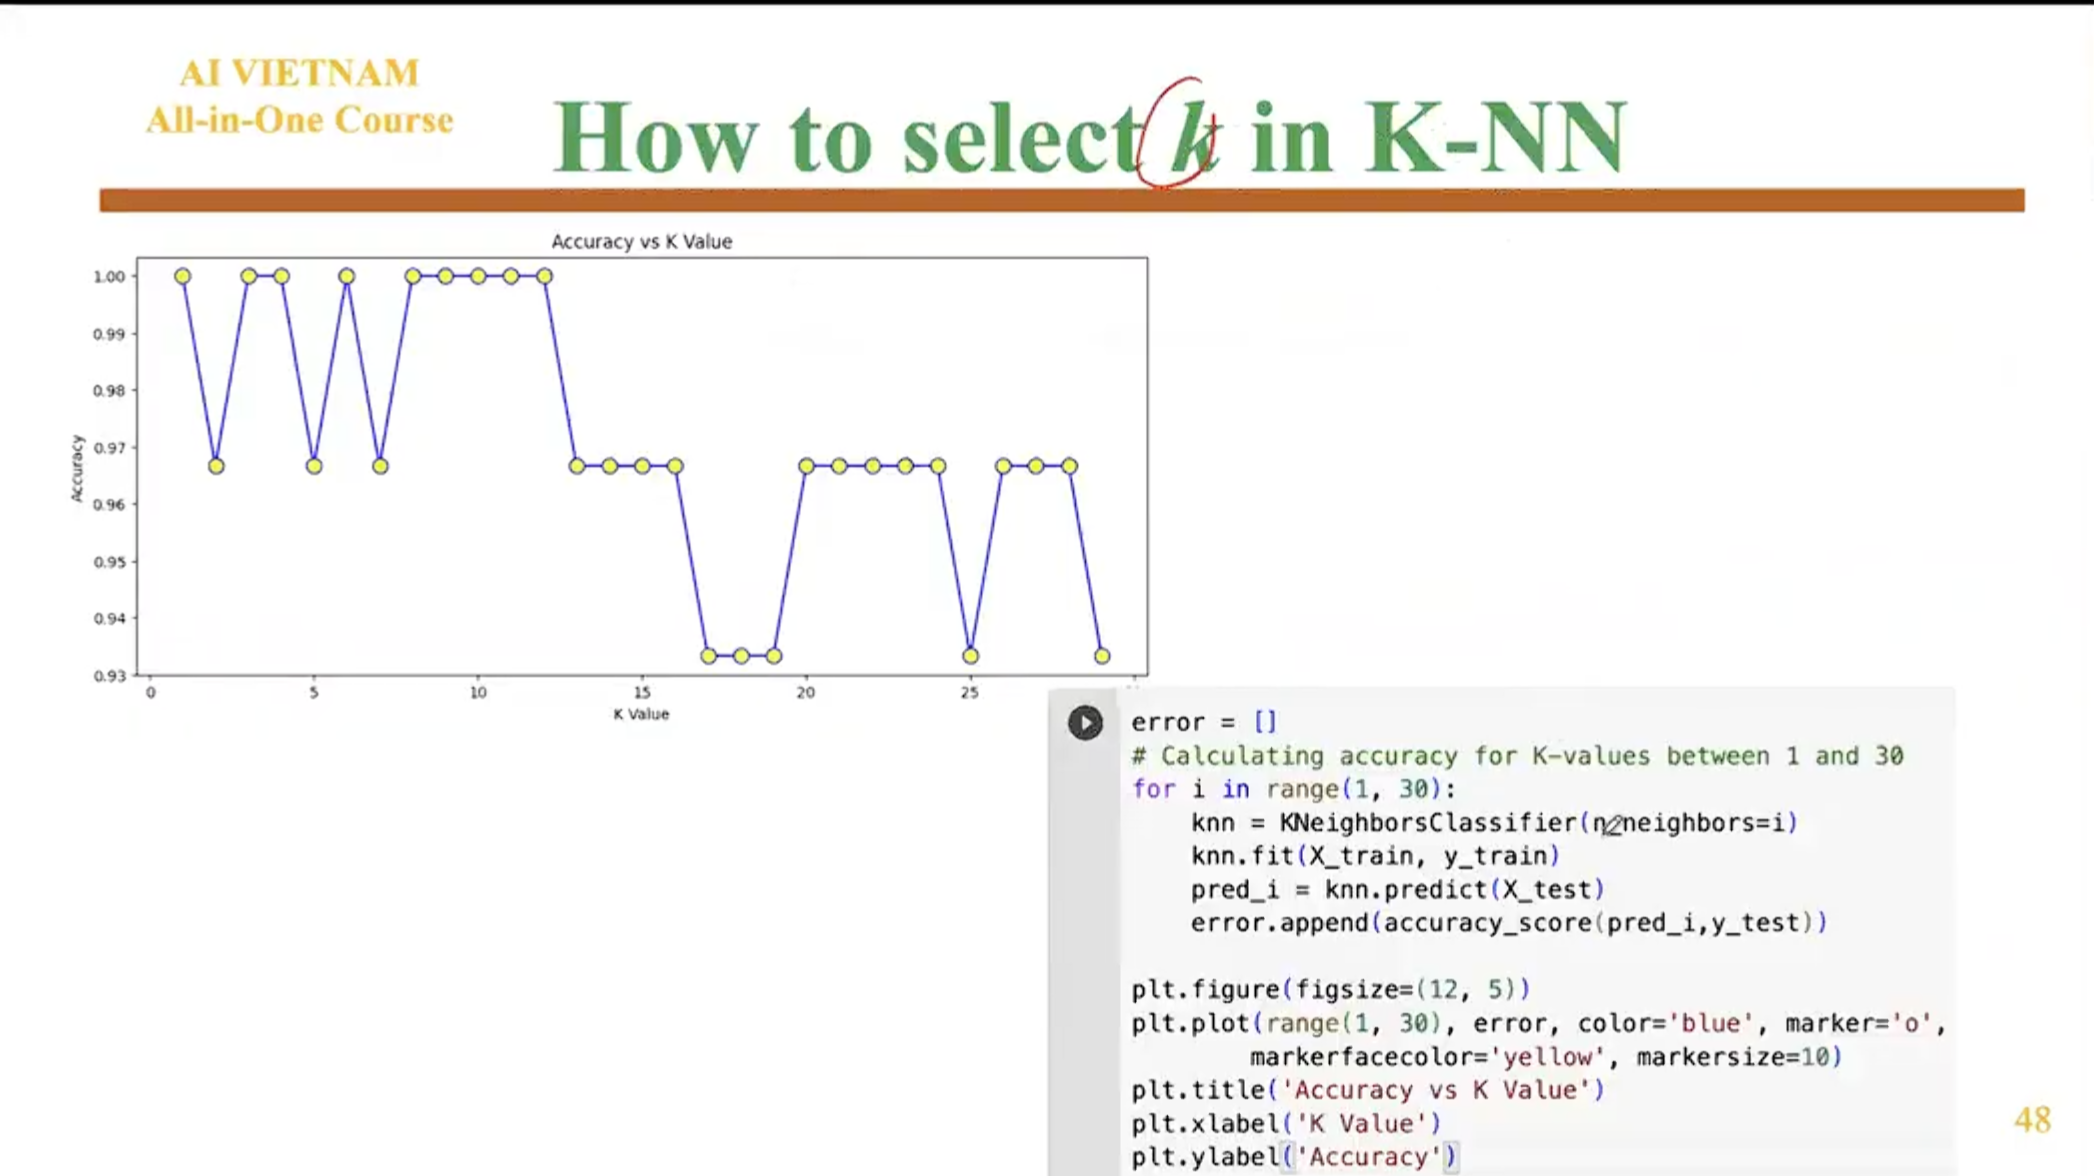
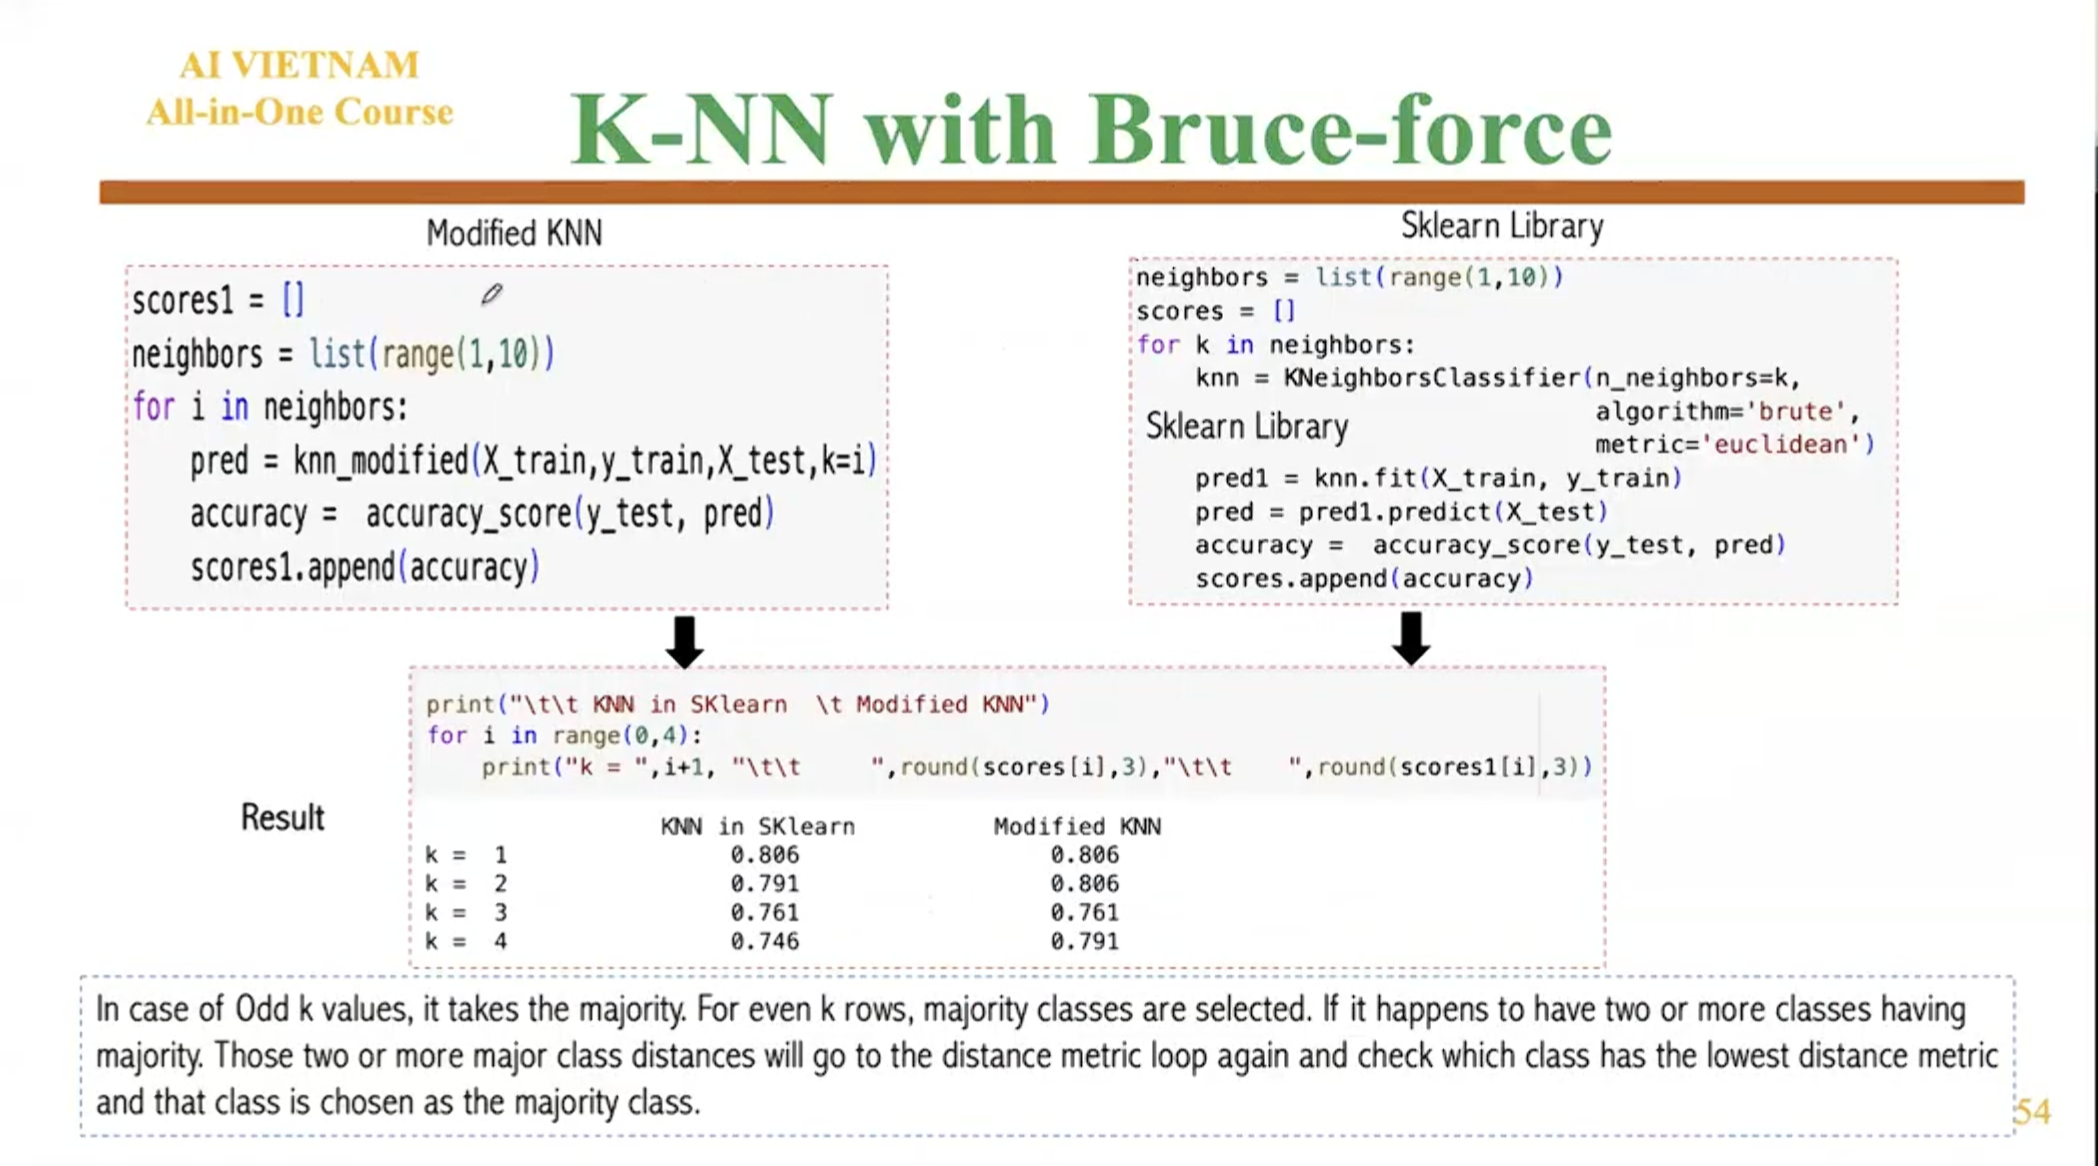

In [2]:
import numpy as np
from collections import Counter

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))
class KNN:
    def __init__(self, k=3):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    def _predict(self, x):
        # Compute distances between x and all samples in the training set
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # Sort by distance and return indices of the first k neighbors
        k_idx = np.argsort(distances)[: self.k]

        # Extract the labels of the k nearest neighbors training samples
        k_neighbor_labels = [self.y_train[i] for i in k_idx]

        # return the most common class label
        most_common = Counter(k_neighbor_labels).most_common(1)
        return most_common[0][0] 

**Hàm Counter**

- Bước 1: Counter(k_neighbor_labels)
    - Hàm Counter sẽ đếm số lần xuất hiện của từng phần tử
    - Ví dụ: k_neighbor_labels = ['A', 'B', 'A'] $\rightarrow$ {'A': 2, 'B': 1}
- Bước 2: .most_common(1)
    - Hàm này yêu cầu lấy ra 1 phần tử phổ biến nhất
        - Kết quả: Nó trả về một list chứa các tuple (giá trị, số lần xuất hiện)
        - Ví dụ: [('A', 2)]: 'A' là nhãn và 2 là số lần xuất hiện
- Bước 3: most_common[0][0]
    - most_common[0]: Truy cập phần tử đầu tiên của list ('A', 2)
    - most_common[0][0]: Truy cập phần tử đầu tiên của tuple đó ('A')

In [3]:
if __name__ == "__main__":
    from matplotlib.colors import ListedColormap
    from sklearn import datasets
    from sklearn.model_selection import train_test_split

    cmap = ListedColormap(["#FF0000", "#00FF00", "#0000FF"])
    
    def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy
    
    iris = datasets.load_iris()
    X, y = iris.data, iris.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=1234
    )

    k = 3
    clf = KNN(k=k)
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    print("KNN classification accuracy", accuracy(y_test, predictions))

KNN classification accuracy 1.0


# Weighted KNN

- Thay vì đếm số lượng "phiếu bầu" ngang hàng nhau (mỗi điểm là 1 phiếu), ta sẽ cho các điểm ở gần có "trọng lượng" phiếu cao hơn các điểm ở xa.
- Công thức thường dùng là lấy nghịch đảo của khoảng cách:
$$w = \frac{1}{d + \epsilon}$$
(Trong đó $\epsilon$ là một số rất nhỏ để tránh chia cho 0).

In [4]:
import numpy as np
from collections import Counter

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))
class WeightedKNN:
    def __init__(self, k = 3):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        k_idx = np.argsort(distances)[:self.k]
        
        # Tính tổng trọng số cho từng lớp
        class_weights = {}
        for i in k_idx:
            label = self.y_train[i]
            dist = distances[i]

            weight = 1 / (dist + 1e-6)
            if label in class_weights:
                class_weights[label] += weight
            else:
                class_weights[label] = weight
        
        return max(class_weights, key=class_weights.get)


In [6]:
if __name__ == "__main__":
    from sklearn import datasets
    from sklearn.model_selection import train_test_split

    def accuracy(y_true, y_pred):
        return np.sum(y_true == y_pred) / len(y_true)

    # Load dữ liệu Iris
    iris = datasets.load_iris()
    X, y = iris.data, iris.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=1234
    )

    # Thử nghiệm với k=4 (số chẵn) để kiểm chứng khả năng xử lý
    k = 4
    clf = WeightedKNN(k=k)
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    print(f"Weighted KNN (với k={k}) classification accuracy: {accuracy(y_test, predictions)*100:.2f}%")

Weighted KNN (với k=4) classification accuracy: 100.00%


# CHOOSING K

k     | Accuracy  
--------------------
1     | 1.0000
2     | 1.0000
3     | 1.0000
4     | 1.0000
5     | 0.9667
6     | 1.0000
7     | 0.9667
8     | 1.0000
9     | 1.0000
10    | 1.0000
11    | 1.0000
12    | 1.0000
13    | 1.0000
14    | 1.0000
15    | 1.0000
16    | 1.0000
17    | 1.0000
18    | 1.0000
19    | 1.0000
20    | 1.0000
21    | 1.0000
22    | 1.0000
23    | 1.0000
24    | 1.0000
25    | 1.0000
26    | 1.0000
27    | 1.0000
28    | 1.0000
29    | 1.0000
30    | 1.0000
--------------------
Giá trị k tốt nhất là: 1 với độ chính xác 1.0000


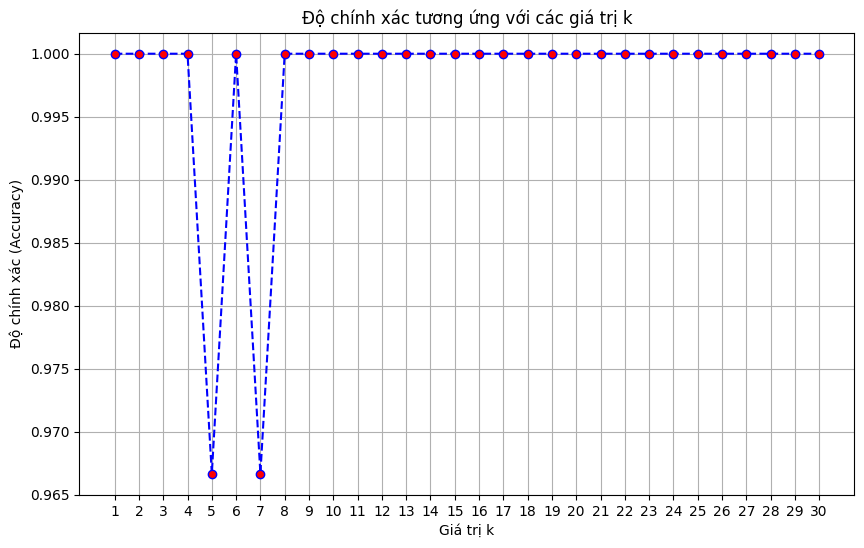

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

iris = datasets.load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

k_range = range(1, 31)
scores = []

print(f"{'k':<5} | {'Accuracy':<10}")
print("-" * 20)

for k in k_range:
    knn = WeightedKNN(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    score = accuracy(y_test, y_pred)
    scores.append(score)

    print(f"{k:<5} | {score:.4f}")

best_k = k_range[np.argmax(scores)]
best_score = max(scores)

print("-" * 20)
print(f"Giá trị k tốt nhất là: {best_k} với độ chính xác {best_score:.4f}")

# 4. Vẽ biểu đồ trực quan hóa
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', linestyle='dashed', color='blue', markerfacecolor='red')
plt.title('Độ chính xác tương ứng với các giá trị k')
plt.xlabel('Giá trị k')
plt.ylabel('Độ chính xác (Accuracy)')
plt.xticks(k_range)
plt.grid(True)
plt.show()